In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from datasets import load_dataset

In [2]:
ds = load_dataset("nikolkoo/SatelliteSegmentation")

In [3]:
ds['train']

Dataset({
    features: ['image', 'mask'],
    num_rows: 790
})

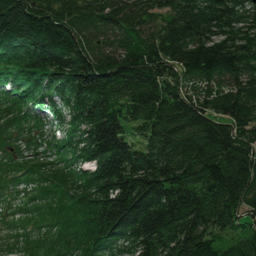

In [4]:
ds['train'][0]['image']

In [5]:
np.array(ds['train'][0]['mask'])

array([[ 0,  0, 10, ..., 10, 30, 10],
       [ 0,  0, 10, ..., 80, 10, 80],
       [ 0,  0, 10, ..., 10, 10, 80],
       ...,
       [ 0,  0, 30, ..., 10, 10, 10],
       [ 0,  0, 30, ..., 10, 10, 10],
       [ 0,  0, 30, ..., 10, 10, 10]], shape=(256, 256), dtype=uint8)

In [6]:
# Remap masks to 0,1,2,etc.

In [7]:
for sample in ds['train']:
    # print(np.array(sample['mask']).shape)
    sample['mask'] = np.array(sample['mask']) / 10

## Problem 1

In [8]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'mask'],
        num_rows: 790
    })
})

In [9]:
train_ds = ds['train']

In [10]:
unique_values = set()
for i, sample in enumerate(train_ds):
    if i == 0:
        print(f"Image shape: {np.array(sample['image']).shape}")
    unique_values.update(np.unique(np.array(sample['mask'])))
num_samples = len(train_ds)
num_classes = len(unique_values)
print(f"Number of samples: {num_samples}")
print(f"Number of classes: {num_classes}")
print(f"Unique values in masks: {np.array(list(unique_values))}")

Image shape: (256, 256, 3)
Number of samples: 790
Number of classes: 11
Unique values in masks: [  0 100  70  40  10  80  50  20  90  60  30]


In [11]:
# ESA WorldCover classes
class_labels = {
    0: "No Data / Unknown",
    10: "Trees",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / sparse vegetation",
    70: "Snow and ice",
    80: "Open water",
    90: "Herbaceous wetland",
    100: "Moss and lichen"
}

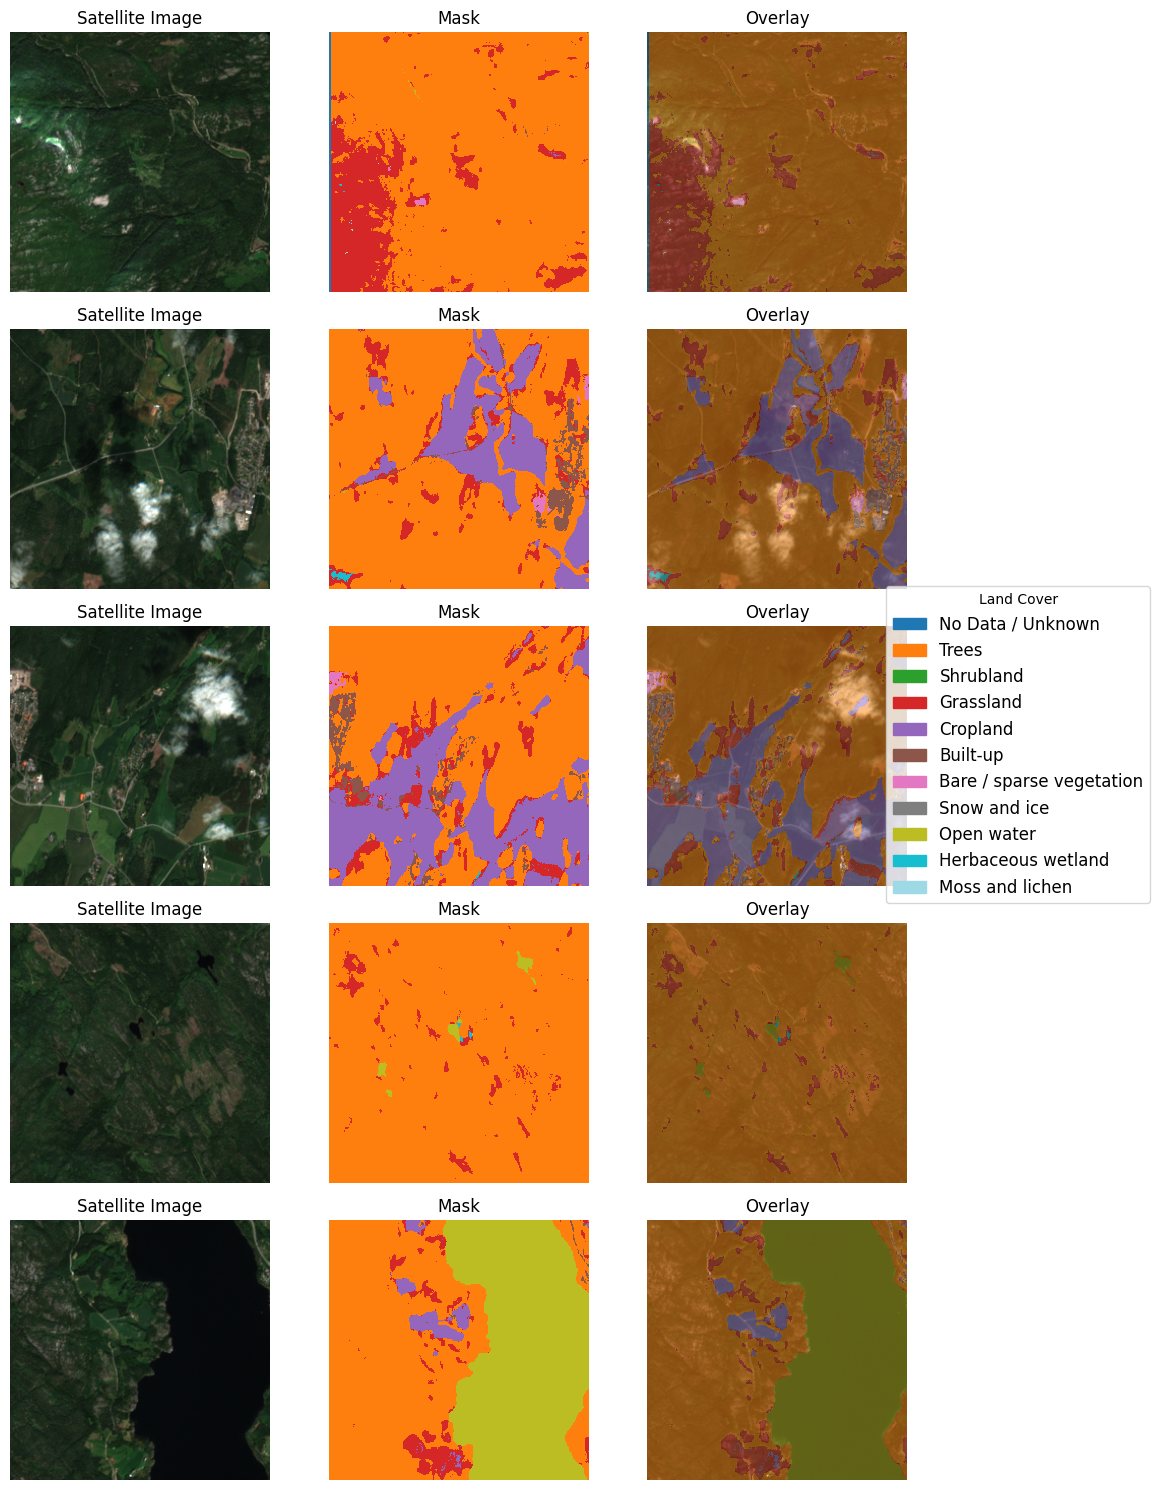

In [12]:
cmap = plt.get_cmap('tab20', 11)
norm = mcolors.Normalize(vmin=0, vmax=100)

fig, axes = plt.subplots(5, 3, figsize=(10, 15))

for i in range(5):
    img = np.array(train_ds[i]['image'])
    mask = np.array(train_ds[i]['mask'])
    
    # Raw image
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Satellite Image")
    axes[i, 0].axis('off')
    
    # Mask
    axes[i, 1].imshow(mask, cmap=cmap, norm=norm, interpolation='nearest')
    axes[i, 1].set_title("Mask")
    axes[i, 1].axis('off')
    
    # Overlay
    axes[i, 2].imshow(img)
    axes[i, 2].imshow(mask, cmap=cmap, norm=norm, alpha=0.5, interpolation='nearest')
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis('off')

# Create the custom legend patches
patches = [mpatches.Patch(color=cmap(norm(val)), label=name) for val, name in class_labels.items()]

# Put legend outside the subplots so it doesnt overlap
fig.legend(handles=patches, loc='center right', bbox_to_anchor=(1.2, 0.5), fontsize=12, title="Land Cover")

plt.tight_layout()
plt.savefig("satellite_samples.png", bbox_inches='tight')
plt.show()

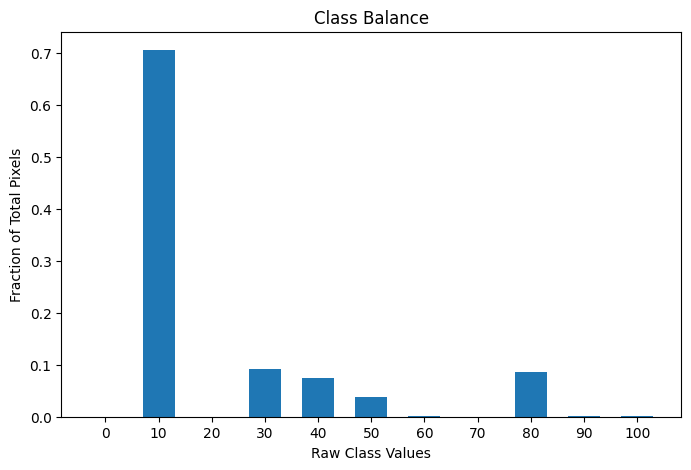

In [13]:
class_counts = {k: 0 for k in range(0, 101, 10)}
total_pixels = 0

for sample in train_ds:
    mask = np.array(sample['mask'])
    unique_vals, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique_vals, counts):
        class_counts[u] += c
    total_pixels += mask.size
    
fractions = {k: v / total_pixels for k, v in class_counts.items()}

plt.figure(figsize=(8, 5))
plt.bar(fractions.keys(), fractions.values(), width=6)
plt.xlabel("Raw Class Values")
plt.ylabel("Fraction of Total Pixels")
plt.title("Class Balance")
plt.xticks(list(fractions.keys()))
plt.savefig("class_balance.png", bbox_inches='tight')
plt.show()

In [14]:
fractions

{0: np.float64(0.0002076740506329114),
 10: np.float64(0.7061678343181369),
 20: np.float64(3.1406064576740504e-05),
 30: np.float64(0.09273706750024723),
 40: np.float64(0.07381558961506131),
 50: np.float64(0.037775450114962424),
 60: np.float64(0.001783733126483386),
 70: np.float64(9.464312203322784e-07),
 80: np.float64(0.0860755244387856),
 90: np.float64(0.0007833166967464399),
 100: np.float64(0.0006214576431467563)}

In [15]:
class SatelliteDataset(Dataset):
    def __init__(self, hf_split, target_size=(256, 256)):
        self.hf_split = hf_split
        self.target_size = target_size
        
    def __len__(self):
        return len(self.hf_split)
        
    def __getitem__(self, idx):
        item = self.hf_split[idx]
        
        image = TF.to_tensor(item['image']) 
        
        mask = torch.tensor(np.array(item['mask']), dtype=torch.int64)
        
        mask = mask // 10
        
        image = TF.resize(image, self.target_size, interpolation=TF.InterpolationMode.BILINEAR)
        
        mask = mask.unsqueeze(0)
        mask = TF.resize(mask, self.target_size, interpolation=TF.InterpolationMode.NEAREST)
        mask = mask.squeeze(0)
        
        return image, mask

split_ds = train_ds.train_test_split(test_size=0.2, seed=42)

train_dataset = SatelliteDataset(split_ds['train'])
val_dataset = SatelliteDataset(split_ds['test'])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# quick test to prove the shapes and types match the rubric
img_batch, mask_batch = next(iter(train_loader))
print(f"Image tensor: {img_batch.shape}, {img_batch.dtype}")
print(f"Mask tensor: {mask_batch.shape}, {mask_batch.dtype}")
print(f"Contiguous mask values check: {torch.unique(mask_batch)}")

Image tensor: torch.Size([8, 3, 256, 256]), torch.float32
Mask tensor: torch.Size([8, 256, 256]), torch.int64
Contiguous mask values check: tensor([1, 3, 4, 5, 6, 8, 9])


### Problem 2

In [16]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        # two convolutions back to back is standard for unet blocks
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

In [17]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=11, features=[16, 32, 64, 128]):
        super(UNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # build the encoder down part
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # bottleneck at the very bottom
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # build the decoder up part
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        # final 1x1 conv to map to the 11 classes
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # run down the encoder and save skips
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        
        # reverse skips so they match the decoder order
        skip_connections = skip_connections[::-1]

        # run up the decoder and staple skips back on
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            
            # glue them together along the channel dimension
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)


In [18]:
# instantiate the lightweight version
model = UNet(in_channels=3, out_channels=11, features=[32, 64, 128, 256])

# calculate parameters for the assignment report
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

# dummy test to prove it matches the (B, 3, H, W) -> (B, C, H, W) requirement
dummy_x = torch.randn((2, 3, 256, 256))
preds = model(dummy_x)
print(f"Output shape: {preds.shape}")

Total trainable parameters: 7763371
Output shape: torch.Size([2, 11, 256, 256])


### Problem 3

In [19]:
def calculate_mean_iou(total_tp, total_fp, total_fn, num_classes=11):
    """Compute mIoU from accumulated TP/FP/FN arrays (one entry per class)."""
    epsilon = 1e-6
    per_class_iou = total_tp / (total_tp + total_fp + total_fn + epsilon)
    return float(np.mean(per_class_iou)), per_class_iou


In [20]:
fractions

{0: np.float64(0.0002076740506329114),
 10: np.float64(0.7061678343181369),
 20: np.float64(3.1406064576740504e-05),
 30: np.float64(0.09273706750024723),
 40: np.float64(0.07381558961506131),
 50: np.float64(0.037775450114962424),
 60: np.float64(0.001783733126483386),
 70: np.float64(9.464312203322784e-07),
 80: np.float64(0.0860755244387856),
 90: np.float64(0.0007833166967464399),
 100: np.float64(0.0006214576431467563)}

In [21]:
class_weights = torch.tensor([1.0 / (num_classes * fractions[k]) for k in sorted(fractions.keys())], dtype=torch.float32)
class_weights

tensor([4.3775e+02, 1.2874e-01, 2.8946e+03, 9.8029e-01, 1.2316e+00, 2.4066e+00,
        5.0966e+01, 9.6055e+04, 1.0562e+00, 1.1606e+02, 1.4628e+02])

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# hardcoded weights based on the inverse-frequency formula
# REPLACE these dummy values with the actual numbers you calculated
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

epochs = 80
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


In [23]:
device

device(type='cuda')

In [24]:
best_iou = 0.0

train_losses = []
val_losses = []
val_ious = []

for epoch in range(epochs):
    # training phase
    model.train()
    running_train_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # validation phase: accumulate TP/FP/FN over the full val set
    model.eval()
    running_val_loss = 0.0
    total_tp = np.zeros(num_classes)
    total_fp = np.zeros(num_classes)
    total_fn = np.zeros(num_classes)

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            running_val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            p = preds.view(-1).cpu().numpy()
            m = masks.view(-1).cpu().numpy()
            for c in range(num_classes):
                tp = int(((p == c) & (m == c)).sum())
                fp = int(((p == c) & (m != c)).sum())
                fn = int(((p != c) & (m == c)).sum())
                total_tp[c] += tp
                total_fp[c] += fp
                total_fn[c] += fn

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    avg_iou, _ = calculate_mean_iou(total_tp, total_fp, total_fn, num_classes)
    val_ious.append(avg_iou)

    if avg_iou > best_iou:
        best_iou = avg_iou
        torch.save(model.state_dict(), 'best_unet_weights.pth')
        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Mean IoU: {avg_iou:.4f} (New Best!)")
    else:
        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Mean IoU: {avg_iou:.4f}")

    scheduler.step()


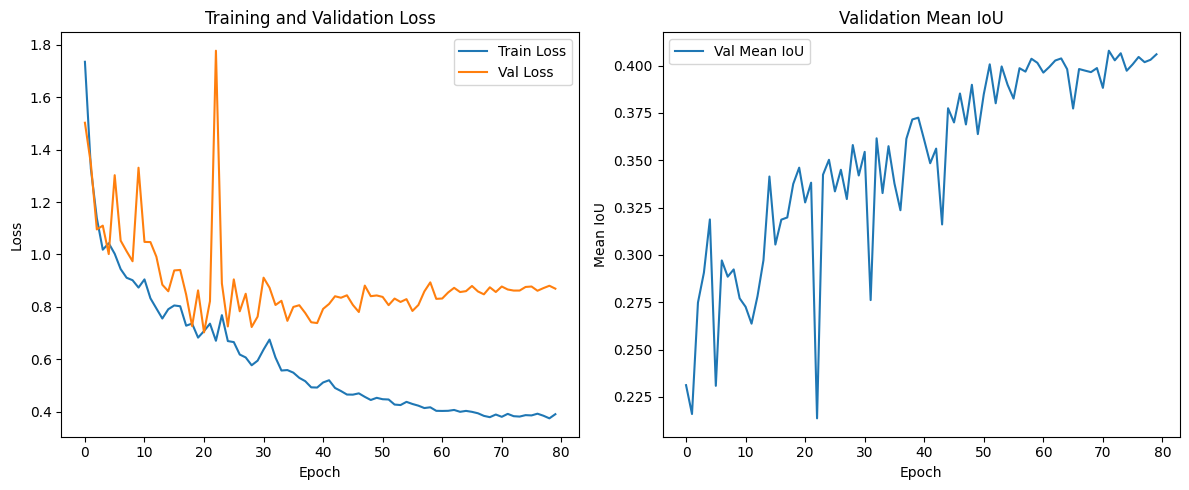

In [25]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(val_ious, label='Val Mean IoU')
plt.xlabel('Epoch')
plt.ylabel('Mean IoU')
plt.title('Validation Mean IoU')
plt.legend()
plt.tight_layout()
plt.savefig("training_curves.png", bbox_inches='tight')
plt.show()

### Problem 4

In [26]:
model.load_state_dict(torch.load('best_unet_weights.pth', map_location=device))
model.eval()

UNet(
  (ups): ModuleList(
    (0): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2))
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
    (3): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), pad

In [27]:
total_tp = np.zeros(num_classes)
total_fp = np.zeros(num_classes)
total_fn = np.zeros(num_classes)

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        for c in range(num_classes):
            # True Positives: Pred is c AND Mask is c
            tp = ((preds == c) & (masks == c)).sum().item()
            # False Positives: Pred is c BUT Mask is NOT c
            fp = ((preds == c) & (masks != c)).sum().item()
            # False Negatives: Pred is NOT c BUT Mask is c
            fn = ((preds != c) & (masks == c)).sum().item()
            
            total_tp[c] += tp
            total_fp[c] += fp
            total_fn[c] += fn

In [28]:
epsilon = 1e-6
per_class_iou = total_tp / (total_tp + total_fp + total_fn + epsilon)

# The mean IoU is just the average of the per-class IoUs
mIoU = np.mean(per_class_iou)
print(f"Overall Validation mIoU: {mIoU:.4f}")

# 2. Plotting the per-class IoU bar chart
original_class_codes = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

Overall Validation mIoU: 0.3212


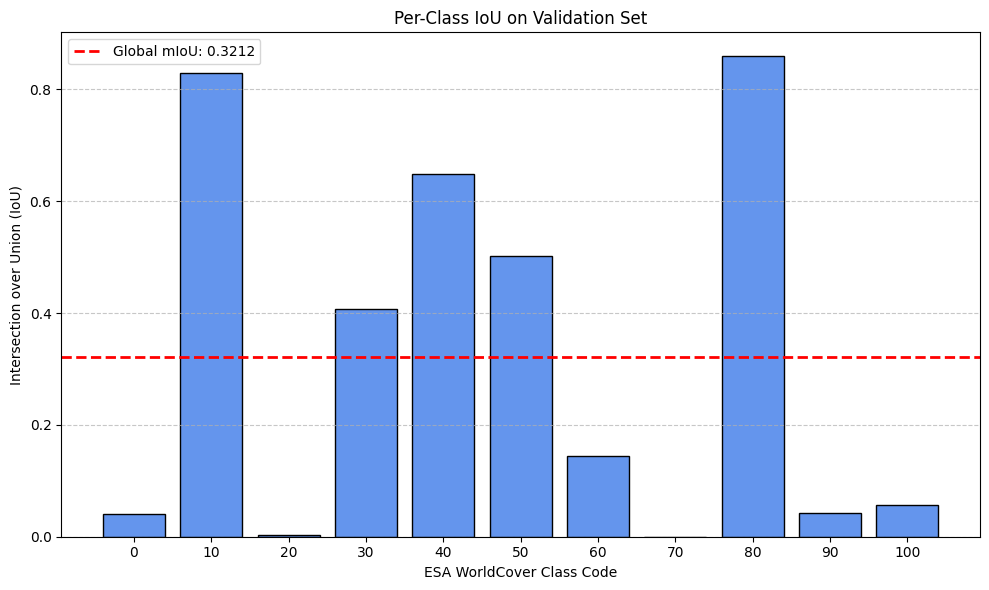

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), per_class_iou, color='cornflowerblue', edgecolor='black')

# Add the horizontal dashed line for mIoU
plt.axhline(y=mIoU, color='red', linestyle='--', linewidth=2, label=f'Global mIoU: {mIoU:.4f}')

# Formatting the plot
plt.xticks(range(num_classes), original_class_codes)
plt.xlabel('ESA WorldCover Class Code')
plt.ylabel('Intersection over Union (IoU)')
plt.title('Per-Class IoU on Validation Set')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("iou_per_class.png", bbox_inches='tight')
plt.show()

In [30]:
def get_sample_miou(pred, mask, num_classes=11):
    pred = pred.view(-1)
    mask = mask.view(-1)
    ious = []
    
    for c in range(num_classes):
        p_inds = pred == c
        t_inds = mask == c
        
        intersection = (p_inds & t_inds).sum().item()
        union = p_inds.sum().item() + t_inds.sum().item() - intersection
        
        # only score classes that are actually physically in this specific ground truth image
        if t_inds.sum().item() > 0:
            ious.append(intersection / max(union, 1))
            
    if len(ious) == 0:
        return 0.0
    return sum(ious) / len(ious)

In [31]:
dataiter = iter(val_loader)
images, masks = next(dataiter)

# we only need 4 for the requirement
images = images[:4].to(device)
masks = masks[:4].to(device)

# run the 4 images through the network
model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

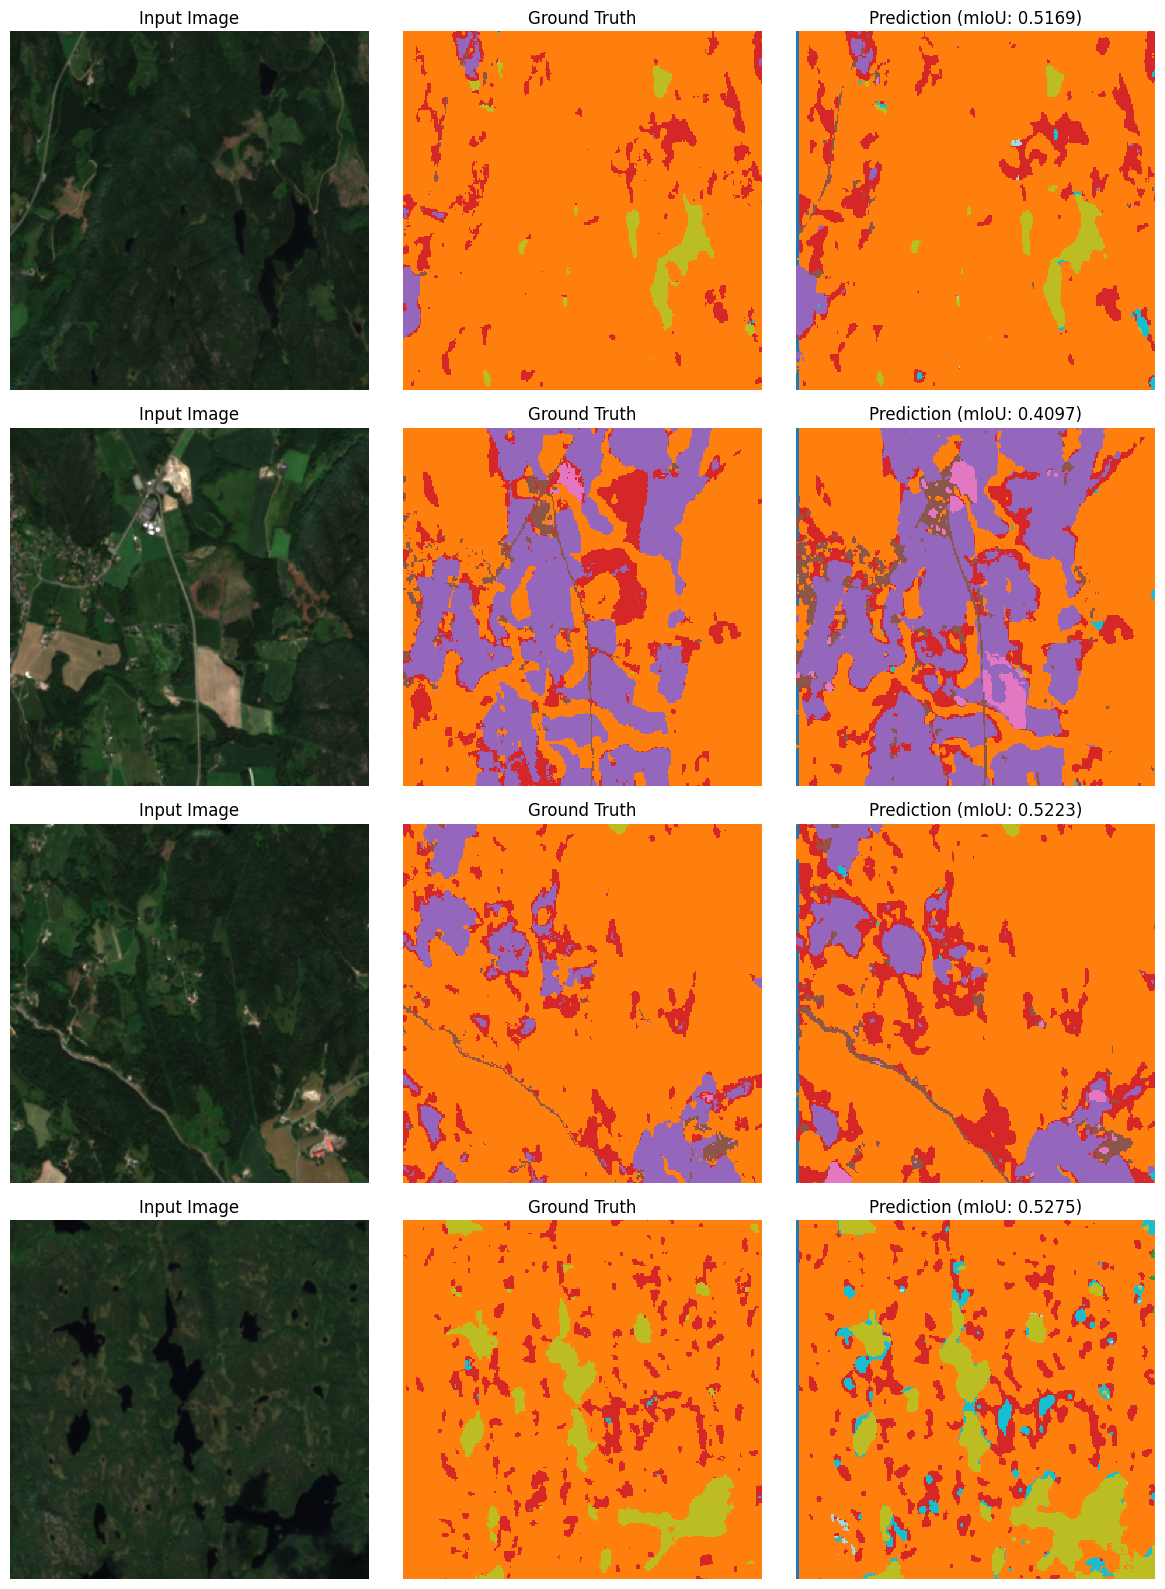

In [32]:
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    # move to cpu and format for matplotlib
    img_np = images[i].cpu().permute(1, 2, 0).numpy()
    
    # multiply by 10 to map contiguous 0-10 back to ESA 0-100 codes for the colors
    true_mask_np = masks[i].cpu().numpy() * 10
    pred_mask_np = preds[i].cpu().numpy() * 10
    
    # calculate the miou using the contiguous tensors
    sample_miou = get_sample_miou(preds[i], masks[i], num_classes=11)
    
    # plot input
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis('off')
    
    # plot true mask
    axes[i, 1].imshow(true_mask_np, cmap=cmap, norm=norm, interpolation='nearest')
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis('off')
    
    # plot prediction
    axes[i, 2].imshow(pred_mask_np, cmap=cmap, norm=norm, interpolation='nearest')
    axes[i, 2].set_title(f"Prediction (mIoU: {sample_miou:.4f})")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig("sample_predictions.png", bbox_inches='tight')
plt.show()